In [12]:
import pandas as pd
import numpy as np
import sys 
import os 


sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<font size="4">Preprocessing and Plots</font>

In [2]:
pp = Preprocessor()
plots_class = Plots()

In [3]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37


array(['<UNK>', 'Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'],
      dtype=object)

In [4]:
df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Shape of the CSV: (20440, 819)


In [5]:
df_merged = pp.merge_datasets(df_clinical_data, df_mRNA_raw_data)

In [6]:
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    ["Tumor-Cancer"] + list(df_merged.columns[1:20441])
]
comparation_df["Tumor-Cancer"].unique()

array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [7]:
comparation_clean_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")


Genes before Treshold: 20440
count    20440.000000
mean        74.003816
std        155.561901
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18537


In [8]:
comparation_clean_df.iloc[:, 1:-1]

,0,1,2,3,5,6,7,8,9,13,...,20428,20429,20430,20431,20432,20433,20434,20435,20436,20437
2,4.4426,153.1452,74.7018,0.0000,0.0000,0.9872,5.5944,0.3291,0.3291,1.3163,...,441.5401,810.8597,95.4340,726.6146,1018.8400,57.5895,960.5923,3007.8157,926.3677,1075.4422
6,4.9419,134.8733,63.6488,0.3658,0.0000,0.3658,4.7554,0.0000,0.7316,2.1948,...,354.8240,420.6676,83.7677,2731.4129,834.3850,51.2117,1092.6383,3032.0988,958.3905,718.7929
7,28.8560,1119.1932,166.7192,0.3152,1.8910,0.0000,3.4668,0.0000,0.0000,0.3152,...,1147.9073,1695.2411,69.0199,610.1481,1775.6067,158.5251,1380.7123,591.2386,1798.9285,1335.6445
8,7.6484,119.4760,80.8081,0.3157,0.0000,0.3157,5.6818,0.6313,0.0000,0.6313,...,499.8548,505.0505,60.6061,546.0859,1014.2045,39.4571,1410.0379,4570.0758,1182.4495,1454.8611
10,9.4309,190.5983,140.0949,0.0000,0.0000,0.7297,5.4725,0.0000,0.3648,0.3648,...,738.3984,1306.8223,26.9974,292.2291,1040.4962,241.5177,681.5031,3473.9146,721.9993,1414.0825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,7.9343,150.6834,540.4278,1.5649,0.5216,0.0000,6.2598,0.0000,0.0000,0.0000,...,253.9854,294.2097,79.2906,443.9228,1083.4637,40.6886,858.1116,4930.6208,2212.8326,665.6234
813,2.2519,115.3378,338.1985,2.0851,0.0000,2.0851,4.1701,0.0000,0.0000,0.0000,...,314.5788,536.6972,45.4545,747.7064,903.6697,10.4254,634.2786,4163.4696,1251.8766,773.1443
814,1.2603,158.3599,210.7460,0.4173,2.0866,2.5039,2.5039,0.4173,0.0000,0.0000,...,438.4517,482.0031,61.3459,334.2723,933.1247,206.1555,479.0819,6621.1789,649.3479,780.3860
815,5.0428,124.6327,323.1185,0.4507,0.0000,8.1118,5.8585,3.1546,0.0000,9.9144,...,342.3885,465.0744,45.5160,797.6566,1038.3055,13.9703,683.1906,5216.7643,1408.7427,713.3844


In [9]:
comparation_clean_df.iloc[:, 1:-1] = np.log2(comparation_clean_df.iloc[:, 1:-1] + 1)


In [10]:
comparation_clean_df.iloc[:, 1:-1]

,0,1,2,3,5,6,7,8,9,13,...,20428,20429,20430,20431,20432,20433,20434,20435,20436,20437
2,2.444296,7.268146,6.242256,0.000000,0.000000,0.990737,2.721241,0.410450,0.410450,1.211822,...,8.789664,9.665087,6.591470,9.507031,9.994127,5.872570,9.909282,11.554980,9.856998,10.072055
6,2.570924,7.086118,6.014552,0.449746,0.000000,0.449746,2.524916,0.000000,0.792106,1.675726,...,8.475020,8.719962,6.405443,11.415960,9.706297,5.706301,10.094920,11.566577,9.905974,9.491438
7,4.899949,10.129532,7.389904,0.395282,1.531569,0.000000,2.159242,0.000000,0.000000,0.395282,...,10.166047,10.728126,6.129693,9.255378,10.794909,7.317640,10.432242,9.210035,10.813724,10.384400
8,3.112433,6.912602,6.354172,0.395831,0.000000,0.395831,2.740237,0.706022,0.000000,0.706022,...,8.968249,8.983138,5.945001,9.095624,9.987555,5.338321,10.462541,12.158318,10.208782,10.507657
10,3.382792,7.581941,7.140522,0.000000,0.000000,0.790522,2.694323,0.000000,0.448690,0.448690,...,9.530208,10.352951,4.807221,8.195884,10.024442,7.921946,9.414692,11.762762,9.497850,10.466670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,3.159355,7.244919,9.080625,1.358903,0.605589,0.000000,2.859930,0.000000,0.000000,0.000000,...,7.994271,8.205596,6.327159,8.797411,10.082766,5.381581,9.746702,12.267846,11.112330,9.380728
813,1.701283,6.862176,8.405986,1.625317,0.000000,1.625317,2.370192,0.000000,0.000000,0.000000,...,8.301856,9.070650,5.537746,9.548256,9.821247,3.514173,9.311246,12.023917,10.291029,9.596459
814,1.176514,7.316145,7.726191,0.503145,1.626019,1.808962,1.808962,0.503145,0.000000,0.000000,...,8.779561,8.915889,5.962223,8.389189,9.867471,7.694570,8.907137,12.693090,9.345068,9.609892
815,2.595217,6.973068,8.340378,0.536749,0.000000,3.187736,2.777893,2.054710,0.000000,3.448161,...,8.423698,8.864416,5.539655,9.641432,10.021404,3.904031,9.418254,12.349216,10.461216,9.480557


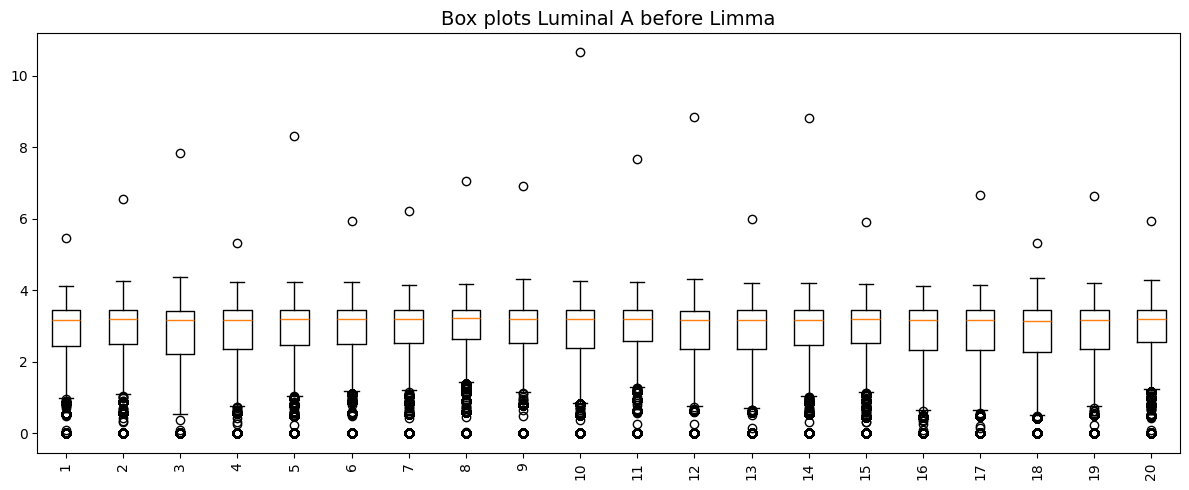

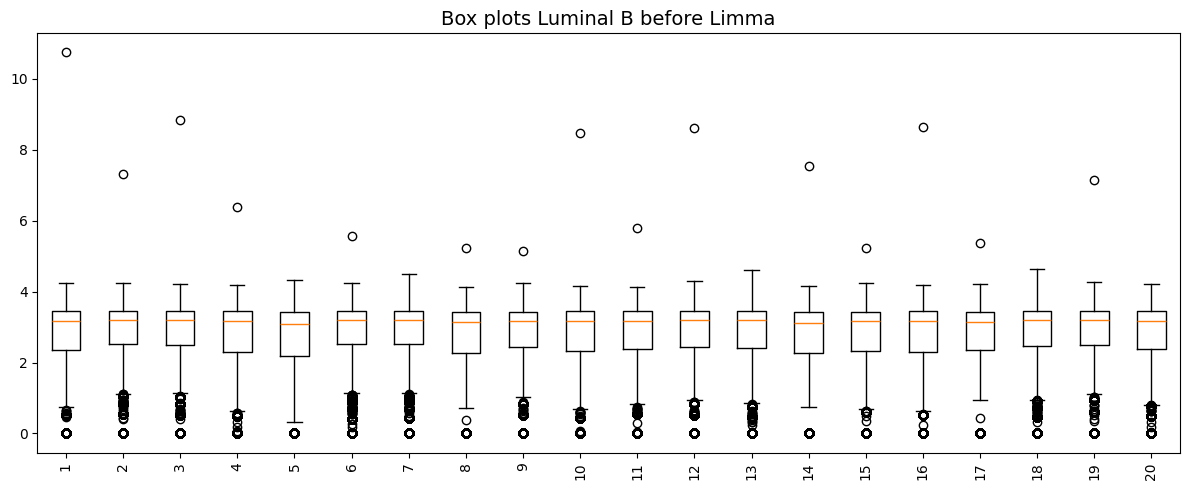

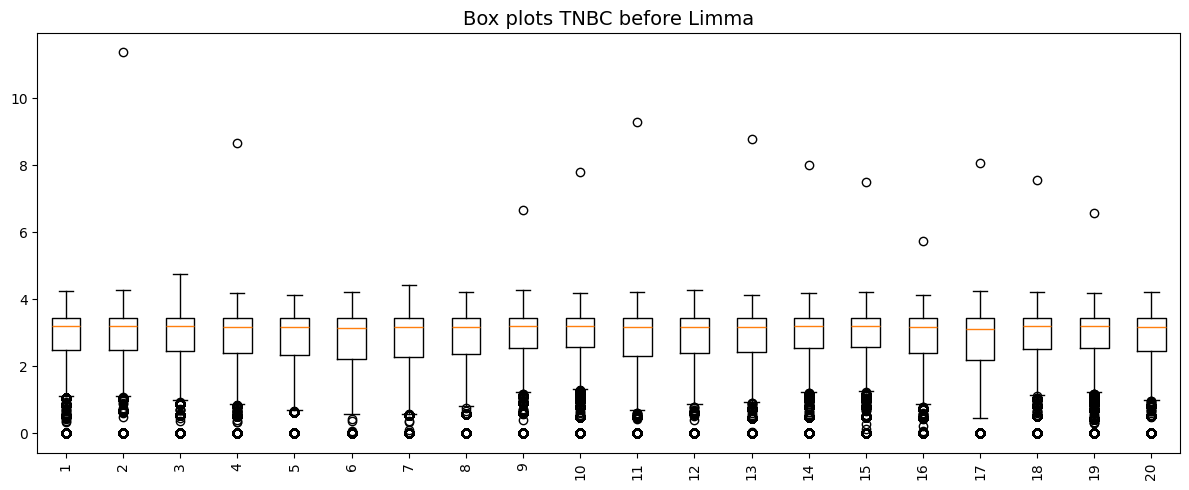

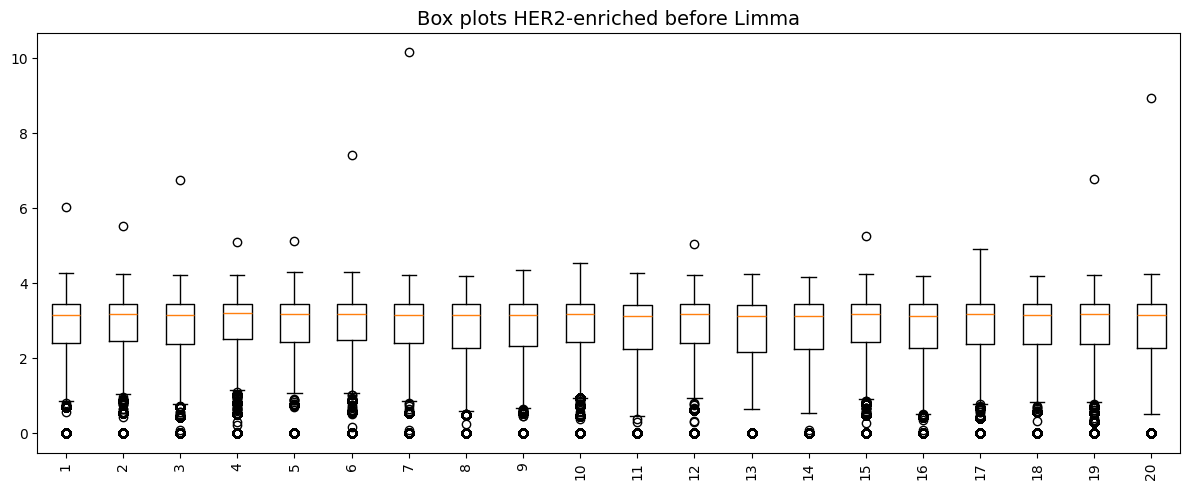

In [13]:
min_range = 1
max_range = 21

plots_class.box_plot(data=comparation_clean_df, title="Box plots Luminal A before Limma",
         type_cancer="Luminal A", range_min=min_range,range_max=max_range)

plots_class.box_plot(data=comparation_clean_df, title="Box plots Luminal B before Limma",
         type_cancer="Luminal B", range_min=min_range,range_max=max_range)

plots_class.box_plot(data=comparation_clean_df, title="Box plots TNBC before Limma",
         type_cancer="TNBC", range_min=min_range,range_max=max_range)

plots_class.box_plot(data=comparation_clean_df, title="Box plots HER2-enriched before Limma",
         type_cancer="HER2-enriched", range_min=min_range,range_max=max_range)


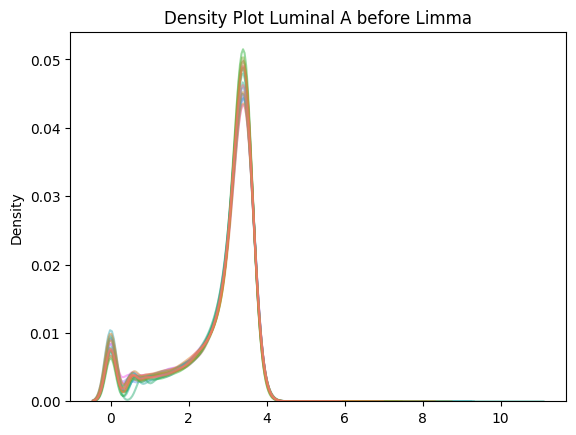

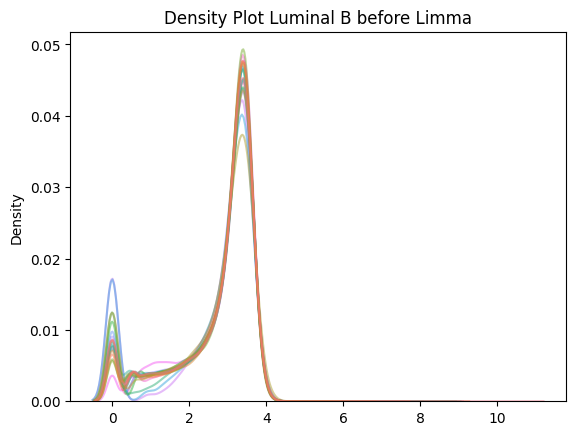

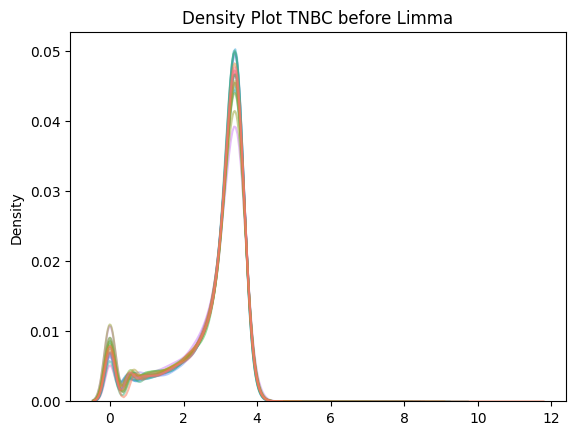

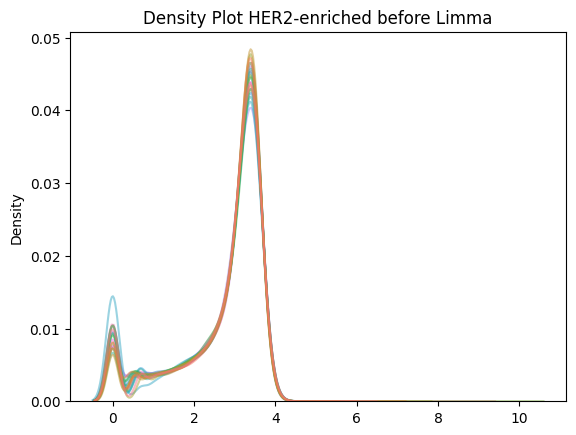

In [14]:

plots_class.density_plot(data=comparation_clean_df, title="Density Plot Luminal A before Limma",
         type_cancer="Luminal A", range_min=min_range,range_max=max_range)

plots_class.density_plot(data=comparation_clean_df, title="Density Plot Luminal B before Limma",
         type_cancer="Luminal B", range_min=min_range,range_max=max_range)

plots_class.density_plot(data=comparation_clean_df, title="Density Plot TNBC before Limma",
         type_cancer="TNBC", range_min=min_range,range_max=max_range)

plots_class.density_plot(data=comparation_clean_df, title="Density Plot HER2-enriched before Limma",
         type_cancer="HER2-enriched", range_min=min_range,range_max=max_range)


In [15]:
plots_class.PCA_4_scatter_matrix_log2(df=comparation_clean_df, cancer_types=["Luminal A", "Luminal B", "TNBC", "HER2-enriched"])

<font size="4">Cox Regression and Multi Cox Regression</font>